In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load data
df = pd.read_csv("/Users/macbook/Desktop/TÀI LIỆU HỌC TẬP UEL/Bài tập mirae/vn30 (1).csv")

# Chuẩn hóa tên cột (nếu cần)
df.columns = df.columns.str.lower()

# Parse time
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date')
elif 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df.sort_values('datetime')

df.reset_index(drop=True, inplace=True)


In [13]:
df['return'] = df['close'].pct_change()
df['volatility'] = df['return'].rolling(10).std()

In [14]:
def RSI(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

df['rsi'] = RSI(df['close'])

In [15]:
ema12 = df['close'].ewm(span=12).mean()
ema26 = df['close'].ewm(span=26).mean()
df['macd'] = ema12 - ema26
df['macd_signal'] = df['macd'].ewm(span=9).mean()
df['macd_hist'] = df['macd'] - df['macd_signal']

In [16]:
ma20 = df['close'].rolling(20).mean()
std20 = df['close'].rolling(20).std()

df['bb_upper'] = ma20 + 2 * std20
df['bb_lower'] = ma20 - 2 * std20
df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / ma20


In [17]:
horizon = 3

future_return = df['close'].shift(-horizon) / df['close'] - 1

df['reversal'] = (
    (df['return'] > 0) & (future_return < 0) |
    (df['return'] < 0) & (future_return > 0)
).astype(int)


In [18]:
features = [
    'return',
    'volatility',
    'rsi',
    'macd',
    'macd_hist',
    'bb_width'
]

data = df[features + ['reversal']].dropna()

X = data[features]
y = data['reversal']


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced'))
])

model.fit(X_train, y_train)


,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [20]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[149  77]
 [ 95  93]]
              precision    recall  f1-score   support

           0       0.61      0.66      0.63       226
           1       0.55      0.49      0.52       188

    accuracy                           0.58       414
   macro avg       0.58      0.58      0.58       414
weighted avg       0.58      0.58      0.58       414



In [ ]:
df['reversal_prob'] = np.nan
df.loc[data.index, 'reversal_prob'] = model.predict_proba(X)[:, 1]

# Flag đảo chiều mạnh
df['reversal_signal'] = (df['reversal_prob'] > 0.7).astype(int)

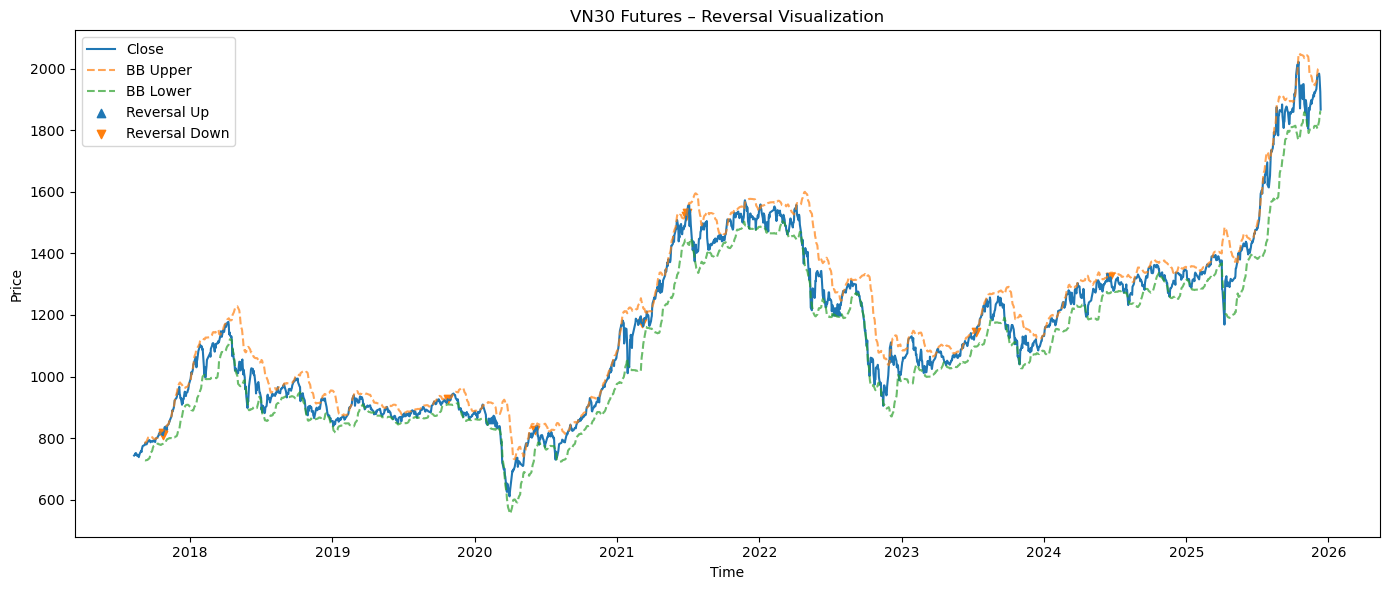

In [ ]:
# Tự động tìm cột thời gian
time_col = None
for col in df.columns:
    parsed = pd.to_datetime(df[col], errors='coerce')
    if parsed.notna().mean() > 0.8:
        df[col] = parsed
        time_col = col
        break

if time_col is None:
    raise ValueError("Không tìm thấy cột thời gian")

df = df.sort_values(time_col).reset_index(drop=True)

# =========================
# INDICATORS
# =========================
# Return
df['return'] = df['close'].pct_change()

# RSI
def RSI(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

df['rsi'] = RSI(df['close'])

# MACD
ema12 = df['close'].ewm(span=12).mean()
ema26 = df['close'].ewm(span=26).mean()
df['macd'] = ema12 - ema26
df['macd_signal'] = df['macd'].ewm(span=9).mean()
df['macd_hist'] = df['macd'] - df['macd_signal']

# Bollinger Bands
ma20 = df['close'].rolling(20).mean()
std20 = df['close'].rolling(20).std()
df['bb_upper'] = ma20 + 2 * std20
df['bb_lower'] = ma20 - 2 * std20

# =========================
# REVERSAL SIGNAL
# =========================
df['reversal_up'] = (df['rsi'] < 30) & (df['macd_hist'] > 0)
df['reversal_down'] = (df['rsi'] > 70) & (df['macd_hist'] < 0)

# =========================
# PLOT
# =========================
plt.figure(figsize=(14,6))

plt.plot(df[time_col], df['close'], label='Close')
plt.plot(df[time_col], df['bb_upper'], linestyle='--', alpha=0.7, label='BB Upper')
plt.plot(df[time_col], df['bb_lower'], linestyle='--', alpha=0.7, label='BB Lower')

# Đảo chiều tăng
plt.scatter(
    df.loc[df['reversal_up'], time_col],
    df.loc[df['reversal_up'], 'close'],
    marker='^',
    label='Reversal Up'
)

# Đảo chiều giảm
plt.scatter(
    df.loc[df['reversal_down'], time_col],
    df.loc[df['reversal_down'], 'close'],
    marker='v',
    label='Reversal Down'
)

plt.title("VN30 Futures – Reversal Visualization")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()


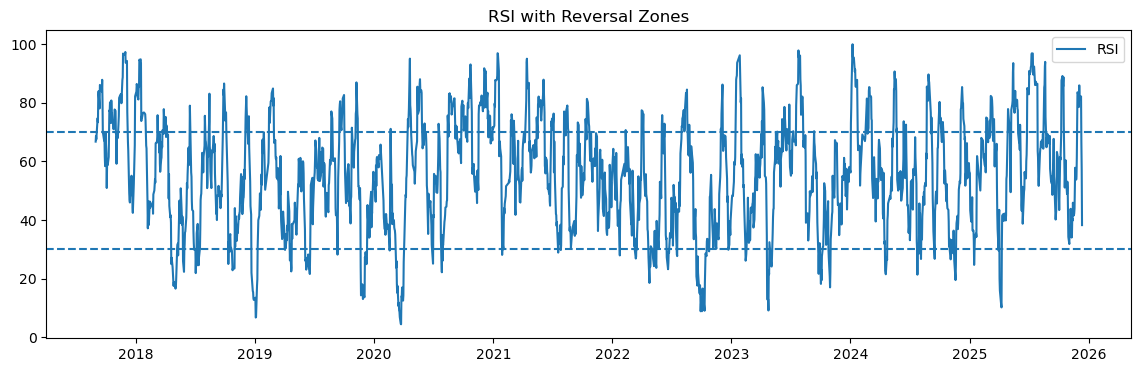

In [ ]:
plt.figure(figsize=(14,4))
plt.plot(df[time_col], df['rsi'], label='RSI')
plt.axhline(70, linestyle='--')
plt.axhline(30, linestyle='--')
plt.title("RSI with Reversal Zones")
plt.legend()
plt.show()